In [18]:
# Import libraries
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.nn.functional import softmax

from packages.utils import process_financial_data, calculate_returns, analyze_trading_strategies

In [19]:
# Load the FinBERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')

# Put model in evaluation mode
model.eval()

def predict_sentiment(text):
    # Encode the text
    encoded_text = tokenizer(text, padding=True, truncation=True, return_tensors='pt')
    
    # Get model output
    with torch.no_grad():
        outputs = model(**encoded_text)
        predictions = softmax(outputs.logits, dim=1)
    
    # Get the predicted class (negative: 0, neutral: 1, positive: 2)
    predicted_class = torch.argmax(predictions, dim=1).item()
    confidence = predictions[0][predicted_class].item()
    
    # Map to trade scores
    sentiment_labels = {0: 'negative', 1: 'neutral', 2: 'positive'}
    sentiment = sentiment_labels[predicted_class]
    
    return sentiment, confidence, predictions.numpy()

In [20]:
# Load dataset
df = pd.read_csv('output2/filtered_data10.csv')  

# Create a timestamp for output files
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

MODEL_NAME = 'FINBERT'

# Filter parameters
STOCK_SYMBOL = None # Set to None to analyze all stocks
EXCHANGE = None  # Set to exchange name (e.g., 'AMEX') to filter by exchange

# Set up the output file paths
if STOCK_SYMBOL:
    output_base = f'output2/{STOCK_SYMBOL}-{timestamp}-{MODEL_NAME}'
elif EXCHANGE:
    output_base = f'output2/{EXCHANGE}-{timestamp}-{MODEL_NAME}'
else:
    output_base = f'output2/ALL-{timestamp}-{MODEL_NAME}'
    
output_path_csv = output_base + '.csv'
output_path_grouped = output_base + '-grouped.csv'
output_path_pdf = output_base + '.pdf'
output_path_analysis = output_base + '_trade_results.csv'

# Create new columns for sentiment prediction and confidence
df['sentiment'] = None
df['confidence'] = None

# Process each headline
for idx, row in df.iterrows():
    headline = row['title']  
    
    try:
        sentiment, confidence, _ = predict_sentiment(headline)
        df.at[idx, 'sentiment'] = sentiment
        df.at[idx, 'confidence'] = confidence
    except Exception as e:
        print(f"Error processing headline {idx}: {e}")
        df.at[idx, 'sentiment'] = 'error'
        df.at[idx, 'confidence'] = 0.0
    
    # Print progress every 100 headlines
    if idx % 100 == 0:
        print(f"Processed {idx} headlines")

# Save the updated dataframe to a new CSV
df.to_csv(output_path_csv, index=False)

Processed 0 headlines
Processed 100 headlines
Processed 200 headlines
Processed 300 headlines
Processed 400 headlines
Processed 500 headlines
Processed 600 headlines
Processed 700 headlines
Processed 800 headlines
Processed 900 headlines
Processed 1000 headlines
Processed 1100 headlines
Processed 1200 headlines
Processed 1300 headlines
Processed 1400 headlines
Processed 1500 headlines
Processed 1600 headlines
Processed 1700 headlines
Processed 1800 headlines
Processed 1900 headlines
Processed 2000 headlines
Processed 2100 headlines
Processed 2200 headlines
Processed 2300 headlines
Processed 2400 headlines
Processed 2500 headlines
Processed 2600 headlines
Processed 2700 headlines
Processed 2800 headlines
Processed 2900 headlines


In [21]:
# Display a sample of the results
print(df[['title', 'sentiment', 'confidence', 'return_pct']].head())

# Optional: Get overall sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:")
print(sentiment_counts)

                                               title sentiment confidence  \
0  Benzinga Pro's Stocks To Watch For Wednesday, ...  positive   0.946532   
1  Autodesk Sees Q4 Adj. EPS $0.86-$0.91 vs $0.93...  positive   0.797811   
2  Autodesk Q3 Adj. EPS $0.78 Beats $0.73 Estimat...  negative   0.698388   
3  Autodesk, Virgin Hyperloop One Report Joint-Ef...  positive   0.850752   
4  Mizuho Maintains Buy on Autodesk, Raises Price...  negative   0.856125   

   return_pct  
0        5.66  
1        5.66  
2        5.66  
3       -0.17  
4        0.20  

Sentiment Distribution:
sentiment
negative    1219
positive     979
neutral      797
Name: count, dtype: int64


In [22]:
# Add trade_score column based on sentiment
df['trade_score'] = 0  # Default value
df.loc[df['sentiment'] == 'positive', 'trade_score'] = 1
df.loc[df['sentiment'] == 'negative', 'trade_score'] = -1

# Set values where confidence is below 50% to 0 so no trade is taken
df.loc[df['confidence'] < 0.5, 'trade_score'] = 0

df

,Unnamed: 0,title,datetime,stock,date,time,offset,exchange,share_code,company_name,minute,entry_price,exit_price,return_pct,month_year,sentiment,confidence,trade_score
0,1203,"Benzinga Pro's Stocks To Watch For Wednesday, ...",2019-11-27 08:42:00-05:00,ADSK,2019-11-27,08:42:00,05:00,NASDAQ,10,Autodesk,42,170.529999,180.179993,5.66,2019-11,positive,0.946532,1
1,1210,Autodesk Sees Q4 Adj. EPS $0.86-$0.91 vs $0.93...,2019-11-26 16:03:00-05:00,ADSK,2019-11-26,16:03:00,05:00,NASDAQ,10,Autodesk,3,170.529999,180.179993,5.66,2019-11,positive,0.797811,1
2,1211,Autodesk Q3 Adj. EPS $0.78 Beats $0.73 Estimat...,2019-11-26 16:02:00-05:00,ADSK,2019-11-26,16:02:00,05:00,NASDAQ,10,Autodesk,2,170.529999,180.179993,5.66,2019-11,negative,0.698388,-1
3,1212,"Autodesk, Virgin Hyperloop One Report Joint-Ef...",2019-11-20 11:01:00-05:00,ADSK,2019-11-20,11:01:00,05:00,NASDAQ,10,Autodesk,1,165.330002,165.050003,-0.17,2019-11,positive,0.850752,1
4,1213,"Mizuho Maintains Buy on Autodesk, Raises Price...",2019-11-20 09:10:00-05:00,ADSK,2019-11-20,09:10:00,05:00,NASDAQ,10,Autodesk,10,165.000000,165.330002,0.20,2019-11,negative,0.856125,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2990,63852,"YY Q3 Adj. EPS $0.9 Beats $0.8 Estimate, Sales...",2019-11-12 18:00:00-05:00,YY,2019-11-12,18:00:00,05:00,NASDAQ,11,JOYY American Depositary,0,58.882599,54.485916,-7.47,2019-11,negative,0.608,-1
2991,63853,"UPDATE: UBS Upgrades YY Buy, Lowers Tgt From $...",2019-09-20 12:44:00-04:00,YY,2019-09-20,12:44:00,04:00,NASDAQ,11,JOYY American Depositary,44,54.832787,53.766140,-1.95,2019-09,neutral,0.912854,0
2992,63854,UBS Upgrades YY to Buy,2019-09-20 09:20:00-04:00,YY,2019-09-20,09:20:00,04:00,NASDAQ,11,JOYY American Depositary,20,54.962867,54.832787,-0.24,2019-09,negative,0.756634,-1
2993,63999,Zoetis Raises Quarterly Dividend From $0.126 T...,2018-12-12 16:27:00-05:00,ZTS,2018-12-12,16:27:00,05:00,NYSE,10,Zoetis,27,87.094821,86.779922,-0.36,2018-12,negative,0.761574,-1


In [23]:
grouped_data = process_financial_data(df)
result = calculate_returns(grouped_data)

output_path_grouped = output_base + '-grouped.csv'
grouped_data.to_csv(output_path_grouped, index=False)
result.to_csv(output_path_analysis, index=False)
print(f"Processed results saved to {output_path_analysis}")

result.head()

Input data contains 2995 headlines
Dropping 0 rows not containing a trade score
Processed results saved to output2/ALL-2025-03-26_19-48-09-FINBERT_trade_results.csv


,date,long_return_pct,short_return_pct,long_short_return_pct,num_stocks,avg_trade_score,long_total_return,short_total_return,long_short_total_return
0,2018-10-01,-0.27,1.65,1.37,3,0.000000,-0.270000,1.650000,1.380000
1,2018-10-02,-0.18,0.16,-0.02,5,-0.200000,-0.449514,1.812640,1.363126
2,2018-10-03,-0.08,0.46,0.38,6,-0.166667,-0.529154,2.280978,1.751824
3,2018-10-04,-0.85,0.61,-0.24,4,0.250000,-1.374657,2.904892,1.530236
4,2018-10-05,-0.03,0.00,-0.03,2,1.000000,-1.404244,2.904892,1.500648


In [24]:
analysis_results = analyze_trading_strategies(result)

# Calculate key performance metrics
long_trades = len(result[result['avg_trade_score'] > 0])
short_trades = len(result[result['avg_trade_score'] < 0])
long_short_trades = long_trades + short_trades

print("\nTrading Strategy Summary:")
print(f"Analysis period: {result['date'].min()} to {result['date'].max()}")
print(f"Total trading days: {len(result)}")

print("\nLong Strategy:")
print(f"Total number of trades: {long_trades}")
print(f"Total return: {result['long_total_return'].iloc[-1]:.2f}%")
print(f"Annualized return: {analysis_results['strategies']['long_return_pct']['annualized_return_pct']:.2f}%")
print(f"Sharpe ratio: {analysis_results['strategies']['long_return_pct']['sharpe_ratio']:.2f}")

print("\nShort Strategy:")
print(f"Total number of trades: {short_trades}")
print(f"Total return: {result['short_total_return'].iloc[-1]:.2f}%")
print(f"Annualized return: {analysis_results['strategies']['short_return_pct']['annualized_return_pct']:.2f}%")
print(f"Sharpe ratio: {analysis_results['strategies']['short_return_pct']['sharpe_ratio']:.2f}")

print("\nLong-Short Strategy:")
print(f"Total number of trades: {long_short_trades}")
print(f"Total return: {result['long_short_total_return'].iloc[-1]:.2f}%")
print(f"Annualized return: {analysis_results['strategies']['long_short_return_pct']['annualized_return_pct']:.2f}%")
print(f"Sharpe ratio: {analysis_results['strategies']['long_short_return_pct']['sharpe_ratio']:.2f}")


Trading Strategy Summary:
Analysis period: 2018-10-01 00:00:00 to 2019-12-30 00:00:00
Total trading days: 311

Long Strategy:
Total number of trades: 118
Total return: 25.29%
Annualized return: 20.05%
Sharpe ratio: 1.09

Short Strategy:
Total number of trades: 151
Total return: 13.36%
Annualized return: 10.69%
Sharpe ratio: 0.66

Long-Short Strategy:
Total number of trades: 269
Total return: 38.65%
Annualized return: 33.00%
Sharpe ratio: 1.38


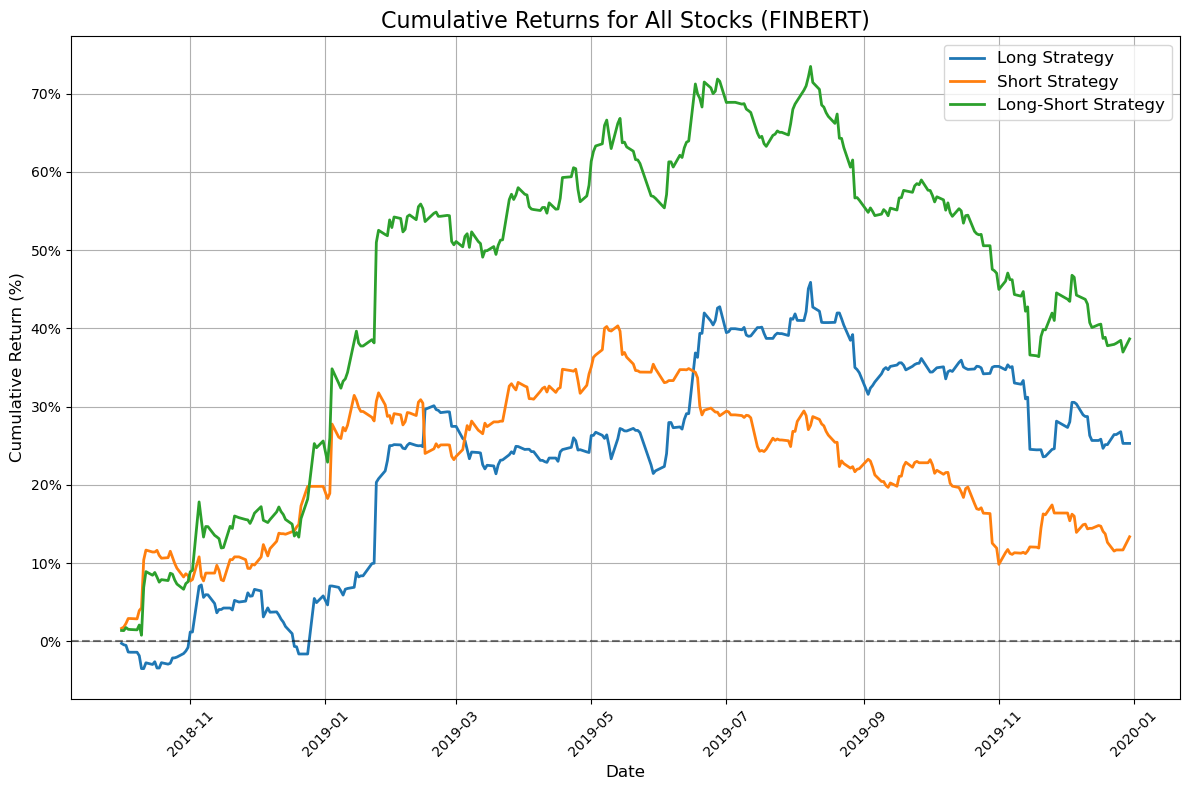

In [25]:
# Plot cumulative returns
plt.figure(figsize=(12, 8))

# Convert date to datetime if it's not already
result['date'] = pd.to_datetime(result['date'])

# Plot each strategy
plt.plot(result['date'], result['long_total_return'], label='Long Strategy', linewidth=2)
plt.plot(result['date'], result['short_total_return'], label='Short Strategy', linewidth=2)
plt.plot(result['date'], result['long_short_total_return'], label='Long-Short Strategy', linewidth=2)

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Add labels and title
plt.title(f'Cumulative Returns for {STOCK_SYMBOL or EXCHANGE or "All Stocks"} ({MODEL_NAME})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Format the y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# Overall conclusion of the analysis
print(f"\nAnalysis Summary for {STOCK_SYMBOL or EXCHANGE or 'All Stocks'} using {MODEL_NAME}:")
print(f"\nTotal headlines analyzed: {len(df)}")
print(f"Total trading days: {len(result)}")

# Determine the best performing strategy
strategy_returns = {
    'Long Strategy': result['long_total_return'].iloc[-1],
    'Short Strategy': result['short_total_return'].iloc[-1],
    'Long-Short Strategy': result['long_short_total_return'].iloc[-1]
}

best_strategy = max(strategy_returns.items(), key=lambda x: x[1])
worst_strategy = min(strategy_returns.items(), key=lambda x: x[1])

print(f"\nBest performing strategy: {best_strategy[0]} with {best_strategy[1]:.2f}% return")
print(f"Worst performing strategy: {worst_strategy[0]} with {worst_strategy[1]:.2f}% return")


Analysis Summary for All Stocks using FINBERT:

Total headlines analyzed: 2995
Total trading days: 311

Best performing strategy: Long-Short Strategy with 38.65% return
Worst performing strategy: Short Strategy with 13.36% return
